In [1]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
import collections
import types
from transformers.models.qwen3_5.modeling_qwen3_5 import Qwen3_5GatedDeltaNet
import copy

/home/joshuaz/sssm-states/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "Qwen/Qwen3.5-4B"

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 54827.50it/s]
The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
/home/joshuaz/sssm-states/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
Loading weights: 100%|██████████| 426/426 [00:00<00:00, 1277.93it/s]


In [4]:
def get_post_hook(layer_name: str, cache_store):
    def post_hook(
        module, args, kwargs, output
    ):
        cache_params = copy.deepcopy(kwargs.get('cache_params', None)) if kwargs.get('cache_params', None) is not None else None
        cache_store.append(cache_params)
    return post_hook

In [5]:
cache_store = []

for name, module in model.named_modules():
    if isinstance(module, Qwen3_5GatedDeltaNet) and "30" in name:
        module.register_forward_hook(get_post_hook(name, cache_store), with_kwargs=True)

In [6]:
messages = [{"role": "user", "content": "Hi there! Who are you?"}]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=5,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
    )

output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
response = tokenizer.decode(output_ids, skip_special_tokens=True)
print(response.strip())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Okay, the user is


In [7]:
#so right now, cache_store is a list of 10 recurrent states.
#each recurrent state is a tensor of shape (1, 32, 128, 128)
# (1: batch size)
# (32: linear value heads)
# (128: per-head key / state dim)
# (128: per-head value dim)

In [8]:
# Generate Deltas relative to the initial state:
def generate_delta(state, state_ref):
    return [state[i] - state_ref[i] for i in range(len(state)) if state[i] is not None]

#deltas shape: list of 9 lists, each cache_store[i] - cache_store[0].
#each inside list is a list of deltas, for each layer (24 total layers)
deltas = [generate_delta(cache_store[i].recurrent_states, cache_store[0].recurrent_states) for i in range(1, len(cache_store))]
torch_deltas = torch.stack([torch.stack(layer, dim=0) for layer in deltas], dim=0)
torch_deltas.shape

torch.Size([4, 24, 1, 32, 128, 128])

In [9]:
S = torch.linalg.svdvals(torch_deltas)

S

tensor([[[[[3.6983e-01, 2.5793e-03, 6.9607e-04,  ..., 1.9961e-12,
            6.4576e-13, 5.9287e-13],
           [4.6893e+00, 3.6609e-01, 2.5026e-02,  ..., 7.5926e-12,
            6.7490e-12, 5.0728e-13],
           [4.1157e-01, 2.6731e-02, 2.7644e-03,  ..., 3.9230e-12,
            2.9880e-12, 2.1638e-12],
           ...,
           [3.9377e-01, 2.5616e-03, 8.5585e-04,  ..., 3.0817e-12,
            2.9515e-12, 1.7493e-12],
           [1.2466e+00, 2.1032e-01, 3.4261e-02,  ..., 2.0347e-12,
            4.5064e-13, 1.8584e-13],
           [1.7247e+00, 7.0435e-02, 4.8609e-02,  ..., 2.2998e-12,
            2.1674e-12, 1.1817e-12]]],


         [[[7.1909e-02, 3.1562e-02, 1.1110e-03,  ..., 1.5108e-12,
            7.2665e-13, 1.7505e-13],
           [1.6340e-01, 1.1152e-02, 2.6694e-03,  ..., 1.3238e-12,
            5.9849e-13, 1.4535e-13],
           [5.1461e-02, 7.9501e-03, 6.1571e-05,  ..., 1.0423e-12,
            8.0131e-13, 1.7650e-13],
           ...,
           [1.9721e-01, 1.9123e-02, 1

In [10]:
def get_s_energy(S, n = -1):
    # passed in batched S, shape (batch, head, dim). Want to do this over dim.
    S_energy = torch.sum(S ** 2, dim=-1, keepdim=True)
    S_nume = S ** 2
    if n == -1:
        return torch.sum(S_nume, dim=-1, keepdim=True) / S_energy
    else:
        return torch.sum(S_nume[..., :n], dim=-1, keepdim=True) / S_energy

In [11]:
s_energy = get_s_energy(S, n=16)

In [12]:
s_vals = torch.flatten(s_energy)

In [13]:
import os

os_dir = "state_spectrum_sweep/experiments/suite_20260318_065636"
os.listdir(os_dir)

total_tensors = []

for file in os.listdir(os_dir):
    if file.endswith(".pt"):
        data = torch.load(os.path.join(os_dir, file))
        total_tensors.append(data)

all_tensors = torch.stack(total_tensors, dim=0)
all_tensors.shape

FileNotFoundError: [Errno 2] No such file or directory: 'state_spectrum_sweep/experiments/suite_20260318_065636'

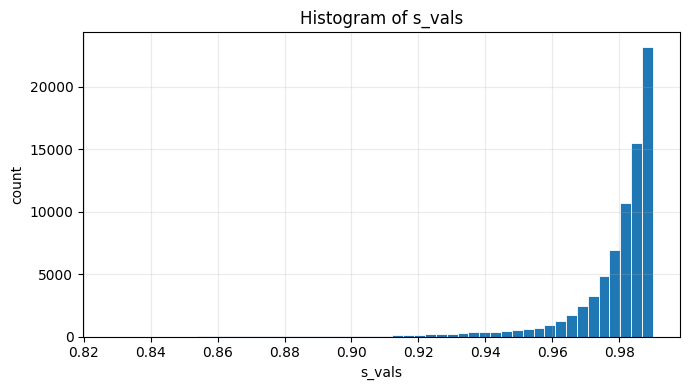

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to a flat CPU numpy array (works for torch tensors and numpy arrays)
if hasattr(s_vals, "detach"):
    data = all_tensors.detach().float().cpu().numpy().ravel()
else:
    data = np.asarray([torch.flatten(all_tensors)]).ravel()

data = data[data < 0.99]
data = data[np.isfinite(data)]

plt.figure(figsize=(7, 4))
plt.hist(data, bins=50, edgecolor="white", linewidth=0.6)
plt.title("Histogram of s_vals")
plt.xlabel("s_vals")
plt.ylabel("count")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
